In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
results_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\results.csv")
status_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\status.csv")
driver_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\drivers.csv")
races_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\races.csv")
constructors_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\constructors.csv")
driver_standing_df = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\driver_standings.csv")
pd.get_option('display.max_columns',None)

20

In [3]:
con1 = pd.merge(results_df,races_df,on='raceId')
con2 = pd.merge(con1,driver_df,on='driverId')
con3 = pd.merge(con2,driver_standing_df,on='driverId')
con4 = pd.merge(con3,constructors_df,on='constructorId')
df = pd.merge(con4,status_df,on='statusId')
pd.get_option('display.max_columns',None)
df.head()

,resultId,raceId_x,driverId,constructorId,number_x,grid,position_x,positionText_x,positionOrder,points_x,...,raceId_y,points_y,position_y,positionText_y,wins,constructorRef,name_y,nationality_y,url,status
0,1,18,1,1,22,1,1,1,1,10.0,...,18,10.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
1,1,18,1,1,22,1,1,1,1,10.0,...,19,14.0,1,1,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
2,1,18,1,1,22,1,1,1,1,10.0,...,20,14.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
3,1,18,1,1,22,1,1,1,1,10.0,...,21,20.0,2,2,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
4,1,18,1,1,22,1,1,1,1,10.0,...,22,28.0,3,3,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished


In [4]:
df.isnull().sum()

resultId             0
raceId_x             0
driverId             0
constructorId        0
number_x             0
grid                 0
position_x           0
positionText_x       0
positionOrder        0
points_x             0
laps                 0
time_x               0
milliseconds         0
fastestLap           0
rank                 0
fastestLapTime       0
fastestLapSpeed      0
statusId             0
year                 0
round                0
circuitId            0
name_x               0
date                 0
time_y               0
url_x                0
driverRef            0
number_y             0
code                 0
forename             0
surname              0
dob                  0
nationality_x        0
url_y                0
driverStandingsId    0
raceId_y             0
points_y             0
position_y           0
positionText_y       0
wins                 0
constructorRef       0
name_y               0
nationality_y        0
url                  0
status     

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
resultId,3364731.0,12047.747856,7927.371034,1.0,4825.0,11121.0,20444.0,25465.0
raceId_x,3364731.0,492.282376,317.172071,1.0,223.0,447.0,782.0,1076.0
driverId,3364731.0,184.762399,243.400286,1.0,20.0,102.0,212.0,855.0
constructorId,3364731.0,37.539315,54.483112,1.0,6.0,17.0,35.0,214.0
grid,3364731.0,9.810997,6.597413,0.0,4.0,9.0,15.0,34.0
positionOrder,3364731.0,11.331430,7.431728,1.0,5.0,10.0,17.0,39.0
points_x,3364731.0,2.819503,5.122316,0.0,0.0,0.0,4.0,50.0
laps,3364731.0,48.028090,25.426385,0.0,31.0,54.0,67.0,200.0
statusId,3364731.0,13.462866,22.476459,1.0,1.0,5.0,12.0,139.0
year,3364731.0,1995.242811,16.915292,1950.0,1983.0,1997.0,2010.0,2022.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3364731 entries, 0 to 3364730
Data columns (total 44 columns):
 #   Column             Dtype  
---  ------             -----  
 0   resultId           int64  
 1   raceId_x           int64  
 2   driverId           int64  
 3   constructorId      int64  
 4   number_x           object 
 5   grid               int64  
 6   position_x         object 
 7   positionText_x     object 
 8   positionOrder      int64  
 9   points_x           float64
 10  laps               int64  
 11  time_x             object 
 12  milliseconds       object 
 13  fastestLap         object 
 14  rank               object 
 15  fastestLapTime     object 
 16  fastestLapSpeed    object 
 17  statusId           int64  
 18  year               int64  
 19  round              int64  
 20  circuitId          int64  
 21  name_x             object 
 22  date               object 
 23  time_y             object 
 24  url_x              object 
 25  driverRef         

In [7]:
#Deleting column which are unwanted
df = df.drop(['url','url_x','position_x','fastestLapTime','positionText_x','time_x','time_y','driverRef',
              'constructorRef','nationality_y','url_y','positionText_y','raceId_y','points_y'],axis=1)

In [8]:
#changing of old column name to meaningful name

column_name = {'number_x':'number','points_x':'points','raceId_x':'raceId','code':'driver_code',
               'name_x':'grand_prix','number_y':'driver_num','nationality_x':'nationality',
                'position_y':'position','name_y':'company_name','milliseconds':'timetaken_in_millisec',
               'fastestLapSpeed':'max_speed'
}
df.rename(columns=column_name,inplace=True)

In [9]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'positionOrder', 'points', 'laps', 'timetaken_in_millisec',
       'fastestLap', 'rank', 'max_speed', 'statusId', 'year', 'round',
       'circuitId', 'grand_prix', 'date', 'driver_num', 'driver_code',
       'forename', 'surname', 'dob', 'nationality', 'driverStandingsId',
       'position', 'wins', 'company_name', 'status'],
      dtype='object')

In [10]:
#Adding two column (forename,surname) to create a single column called driver_name
df['driver_name'] = df['forename'] + ' ' +df['surname']

In [11]:
df=df.drop(['forename','surname'],axis=1)

In [12]:
## converting to date,dob format from string 
df['date'] = pd.to_datetime(df.date)
df['dob'] = pd.to_datetime(df.dob)

C:\Users\Sam\AppData\Local\Temp\ipykernel_23036\949398181.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df.date)


In [13]:
from datetime import datetime
#calculating driver's age and creating it as a new column
dates = datetime.today() - df['dob']
age = dates.dt.days/365

df['age'] = round(age)

In [14]:
#changing datatype 

l = ['number','timetaken_in_millisec','rank','max_speed','fastestLap','driver_num']

for i in l:
    df[i]=pd.to_numeric(df[i],errors='coerce')

In [15]:
df.drop('driver_num',axis=1,inplace=True)

In [16]:
# seperating categorical and numerical columns for understading 

cat = []
num = []

for i in df.columns:
    if df[i].dtype == 'O':
        cat.append(i)
    else:
        num.append(i)

In [17]:
df[cat].head()

,grand_prix,driver_code,nationality,company_name,status,driver_name
0,Australian Grand Prix,HAM,British,McLaren,Finished,Lewis Hamilton
1,Australian Grand Prix,HAM,British,McLaren,Finished,Lewis Hamilton
2,Australian Grand Prix,HAM,British,McLaren,Finished,Lewis Hamilton
3,Australian Grand Prix,HAM,British,McLaren,Finished,Lewis Hamilton
4,Australian Grand Prix,HAM,British,McLaren,Finished,Lewis Hamilton


In [18]:
df[num].head()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,...,statusId,year,round,circuitId,date,dob,driverStandingsId,position,wins,age
0,1,18,1,1,22.0,1,1,10.0,58,5690616.0,...,1,2008,1,1,2008-03-16,1985-01-07,1,1,1,41.0
1,1,18,1,1,22.0,1,1,10.0,58,5690616.0,...,1,2008,1,1,2008-03-16,1985-01-07,9,1,1,41.0
2,1,18,1,1,22.0,1,1,10.0,58,5690616.0,...,1,2008,1,1,2008-03-16,1985-01-07,27,3,1,41.0
3,1,18,1,1,22.0,1,1,10.0,58,5690616.0,...,1,2008,1,1,2008-03-16,1985-01-07,48,2,1,41.0
4,1,18,1,1,22.0,1,1,10.0,58,5690616.0,...,1,2008,1,1,2008-03-16,1985-01-07,69,3,1,41.0


In [19]:
df.isnull().sum()/len(df)*100

resultId                  0.000000
raceId                    0.000000
driverId                  0.000000
constructorId             0.000000
number                    0.004755
grid                      0.000000
positionOrder             0.000000
points                    0.000000
laps                      0.000000
timetaken_in_millisec    62.815690
fastestLap               63.424624
rank                     62.531834
max_speed                63.424624
statusId                  0.000000
year                      0.000000
round                     0.000000
circuitId                 0.000000
grand_prix                0.000000
date                      0.000000
driver_code               0.000000
dob                       0.000000
nationality               0.000000
driverStandingsId         0.000000
position                  0.000000
wins                      0.000000
company_name              0.000000
status                    0.000000
driver_name               0.000000
age                 

In [20]:
#filling the null values 

df[['rank','fastestLap']] = df[['rank','fastestLap']].fillna(0)
df['timetaken_in_millisec'] = df['timetaken_in_millisec'].fillna(df['timetaken_in_millisec'].mean())
df['max_speed']  = df['max_speed'].fillna(df['max_speed'].mean())
df['number'] = df['number'].fillna(0)

In [21]:
df_circuits = pd.read_csv(r"C:\Users\Sam\Downloads\archive (11)\circuits.csv")
df_circuits.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [22]:
#Mapping all the race circuits around the words to a Map 

import folium

corrdinates = []
for lat,lag in zip(df_circuits['lat'],df_circuits['lng']):
    corrdinates.append([lat,lag])
maps = folium.Map(zoom_start=2,title='Stamen Watercolor')


for i,j in zip(corrdinates,df_circuits.name):
    makers= folium.Marker(
        location = i,
        icon = folium.Icon(icon='star',color='cadetbule'),
        popup="<stong>{}</stong>".format(j))
    makers.add_to(maps)
maps

C:\Users\Sam\AppData\Local\Temp\ipykernel_23036\417928852.py:14: UserWarning: color argument of Icon should be one of: {'white', 'orange', 'darkred', 'lightred', 'lightgray', 'darkpurple', 'lightblue', 'lightgreen', 'gray', 'blue', 'cadetblue', 'darkblue', 'beige', 'purple', 'black', 'pink', 'red', 'darkgreen', 'green'}.
  icon = folium.Icon(icon='star',color='cadetbule'),


Filtering data by the driver who finished the race successfully

In [23]:
df_fin = df[df['status'] == 'Finished' ]
df_fin.tail()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,...,driver_code,dob,nationality,driverStandingsId,position,wins,company_name,status,driver_name,age
3363584,25457,1076,840,117,18.0,19,12,0.0,58,5355146.0,...,STR,1998-10-29,Canadian,70728,13,0,Aston Martin,Finished,Lance Stroll,27.0
3363585,25457,1076,840,117,18.0,19,12,0.0,58,5355146.0,...,STR,1998-10-29,Canadian,70749,13,0,Aston Martin,Finished,Lance Stroll,27.0
3363586,25457,1076,840,117,18.0,19,12,0.0,58,5355146.0,...,STR,1998-10-29,Canadian,71263,12,0,Aston Martin,Finished,Lance Stroll,27.0
3363587,25457,1076,840,117,18.0,19,12,0.0,58,5355146.0,...,STR,1998-10-29,Canadian,71283,16,0,Aston Martin,Finished,Lance Stroll,27.0
3363588,25457,1076,840,117,18.0,19,12,0.0,58,5355146.0,...,STR,1998-10-29,Canadian,71303,18,0,Aston Martin,Finished,Lance Stroll,27.0


In [24]:
mean = df['max_speed'].mean()
mean2 = df['fastestLap'].mean()

In [25]:
df = df[df['max_speed']>mean]

In [26]:
df = df[df['fastestLap']>mean2]

In [27]:
# filtering the data by mean of driver's age and events after year 2012

df = df[(df['age'] < df['age'].mean()) & (df['year']>2012)]
df

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,...,driver_code,dob,nationality,driverStandingsId,position,wins,company_name,status,driver_name,age
2743332,21714,880,20,9,1.0,1,3,15.0,58,5.425571e+06,...,VET,1987-07-03,German,90,22,0,Red Bull,Finished,Sebastian Vettel,39.0
2743333,21714,880,20,9,1.0,1,3,15.0,58,5.425571e+06,...,VET,1987-07-03,German,112,12,0,Red Bull,Finished,Sebastian Vettel,39.0
2743334,21714,880,20,9,1.0,1,3,15.0,58,5.425571e+06,...,VET,1987-07-03,German,134,14,0,Red Bull,Finished,Sebastian Vettel,39.0
2743335,21714,880,20,9,1.0,1,3,15.0,58,5.425571e+06,...,VET,1987-07-03,German,156,14,0,Red Bull,Finished,Sebastian Vettel,39.0
2743336,21714,880,20,9,1.0,1,3,15.0,58,5.425571e+06,...,VET,1987-07-03,German,178,15,0,Red Bull,Finished,Sebastian Vettel,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3364582,25464,1076,20,117,5.0,17,19,0.0,22,5.950500e+06,...,VET,1987-07-03,German,70670,12,0,Aston Martin,Accident,Sebastian Vettel,39.0
3364583,25464,1076,20,117,5.0,17,19,0.0,22,5.950500e+06,...,VET,1987-07-03,German,70691,12,0,Aston Martin,Accident,Sebastian Vettel,39.0
3364584,25464,1076,20,117,5.0,17,19,0.0,22,5.950500e+06,...,VET,1987-07-03,German,70733,12,0,Aston Martin,Accident,Sebastian Vettel,39.0
3364585,25464,1076,20,117,5.0,17,19,0.0,22,5.950500e+06,...,VET,1987-07-03,German,70754,12,0,Aston Martin,Accident,Sebastian Vettel,39.0


In [28]:
df.drop('date',axis=1,inplace=True)
df.drop('dob',axis=1,inplace=True)

In [29]:
df.skew(numeric_only=True)

resultId                -0.378560
raceId                  -0.419252
driverId                -0.700910
constructorId            0.703185
number                   1.121111
grid                     0.447714
positionOrder            0.470480
points                   0.712422
laps                    -0.212565
timetaken_in_millisec    2.898192
fastestLap              -0.213416
rank                     0.439607
max_speed                0.647125
statusId                 6.647331
year                    -0.369531
round                    0.022684
circuitId                0.843579
driverStandingsId       -3.895371
position                 0.482548
wins                     2.930688
age                     -0.593363
dtype: float64

In [47]:
# outlier removal 
q1 = df.quantile(0.25,numeric_only=True)
q3 = df.quantile(0.75,numeric_only=True)
iqr = q3 - q1 
num_df = df.select_dtypes(include='number')
df = df[~((num_df < (q1 - 1.5*iqr)) | (num_df > (q3 + 1.5*iqr))).any(axis=1)]
df.head()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,...,grand_prix,driver_code,nationality,driverStandingsId,position,wins,company_name,status,driver_name,age
2744516,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,Australian Grand Prix,DIR,British,64699,10,0,Force India,Finished,Paul di Resta,40.0
2744517,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,Australian Grand Prix,DIR,British,64393,13,0,Force India,Finished,Paul di Resta,40.0
2744518,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,Australian Grand Prix,DIR,British,64417,14,0,Force India,Finished,Paul di Resta,40.0
2744519,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,Australian Grand Prix,DIR,British,64441,14,0,Force India,Finished,Paul di Resta,40.0
2744520,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,Australian Grand Prix,DIR,British,64465,15,0,Force India,Finished,Paul di Resta,40.0


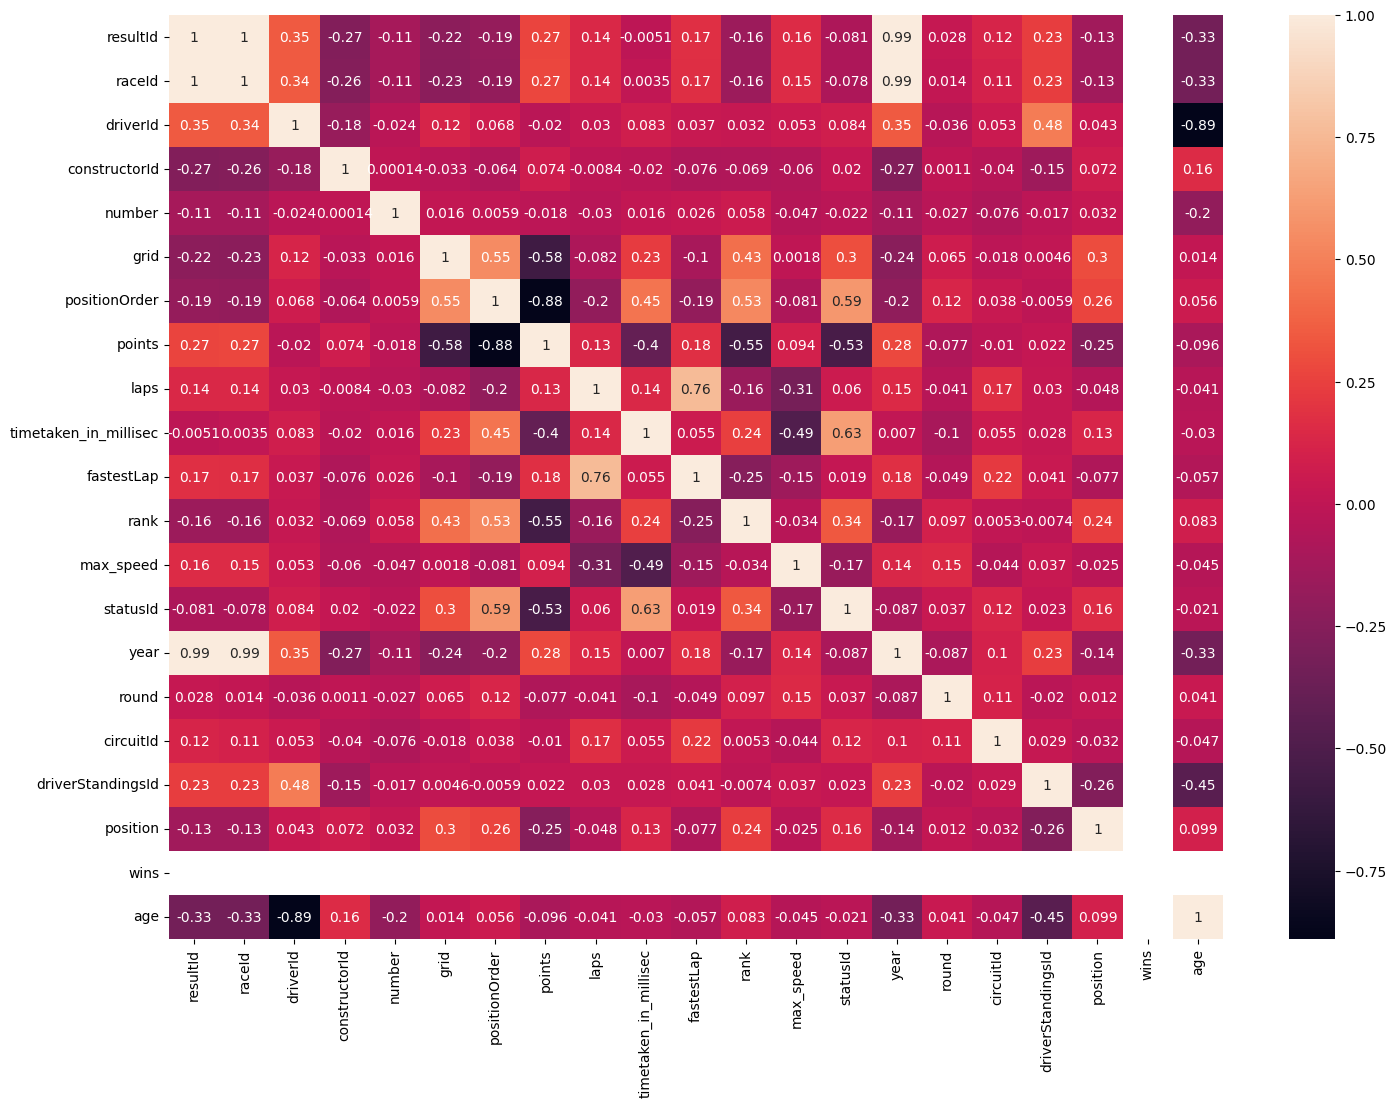

In [54]:
num_df = df.select_dtypes(include = 'number')
# heatmap
plt.figure(figsize=(17,12))
sns.heatmap(num_df.corr(),annot=True)
plt.show()

In [63]:
num.remove('date')
num.remove('dob')

C:\Users\Sam\AppData\Local\Temp\ipykernel_23036\2950900593.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[i],fill=True,color='darkblue')


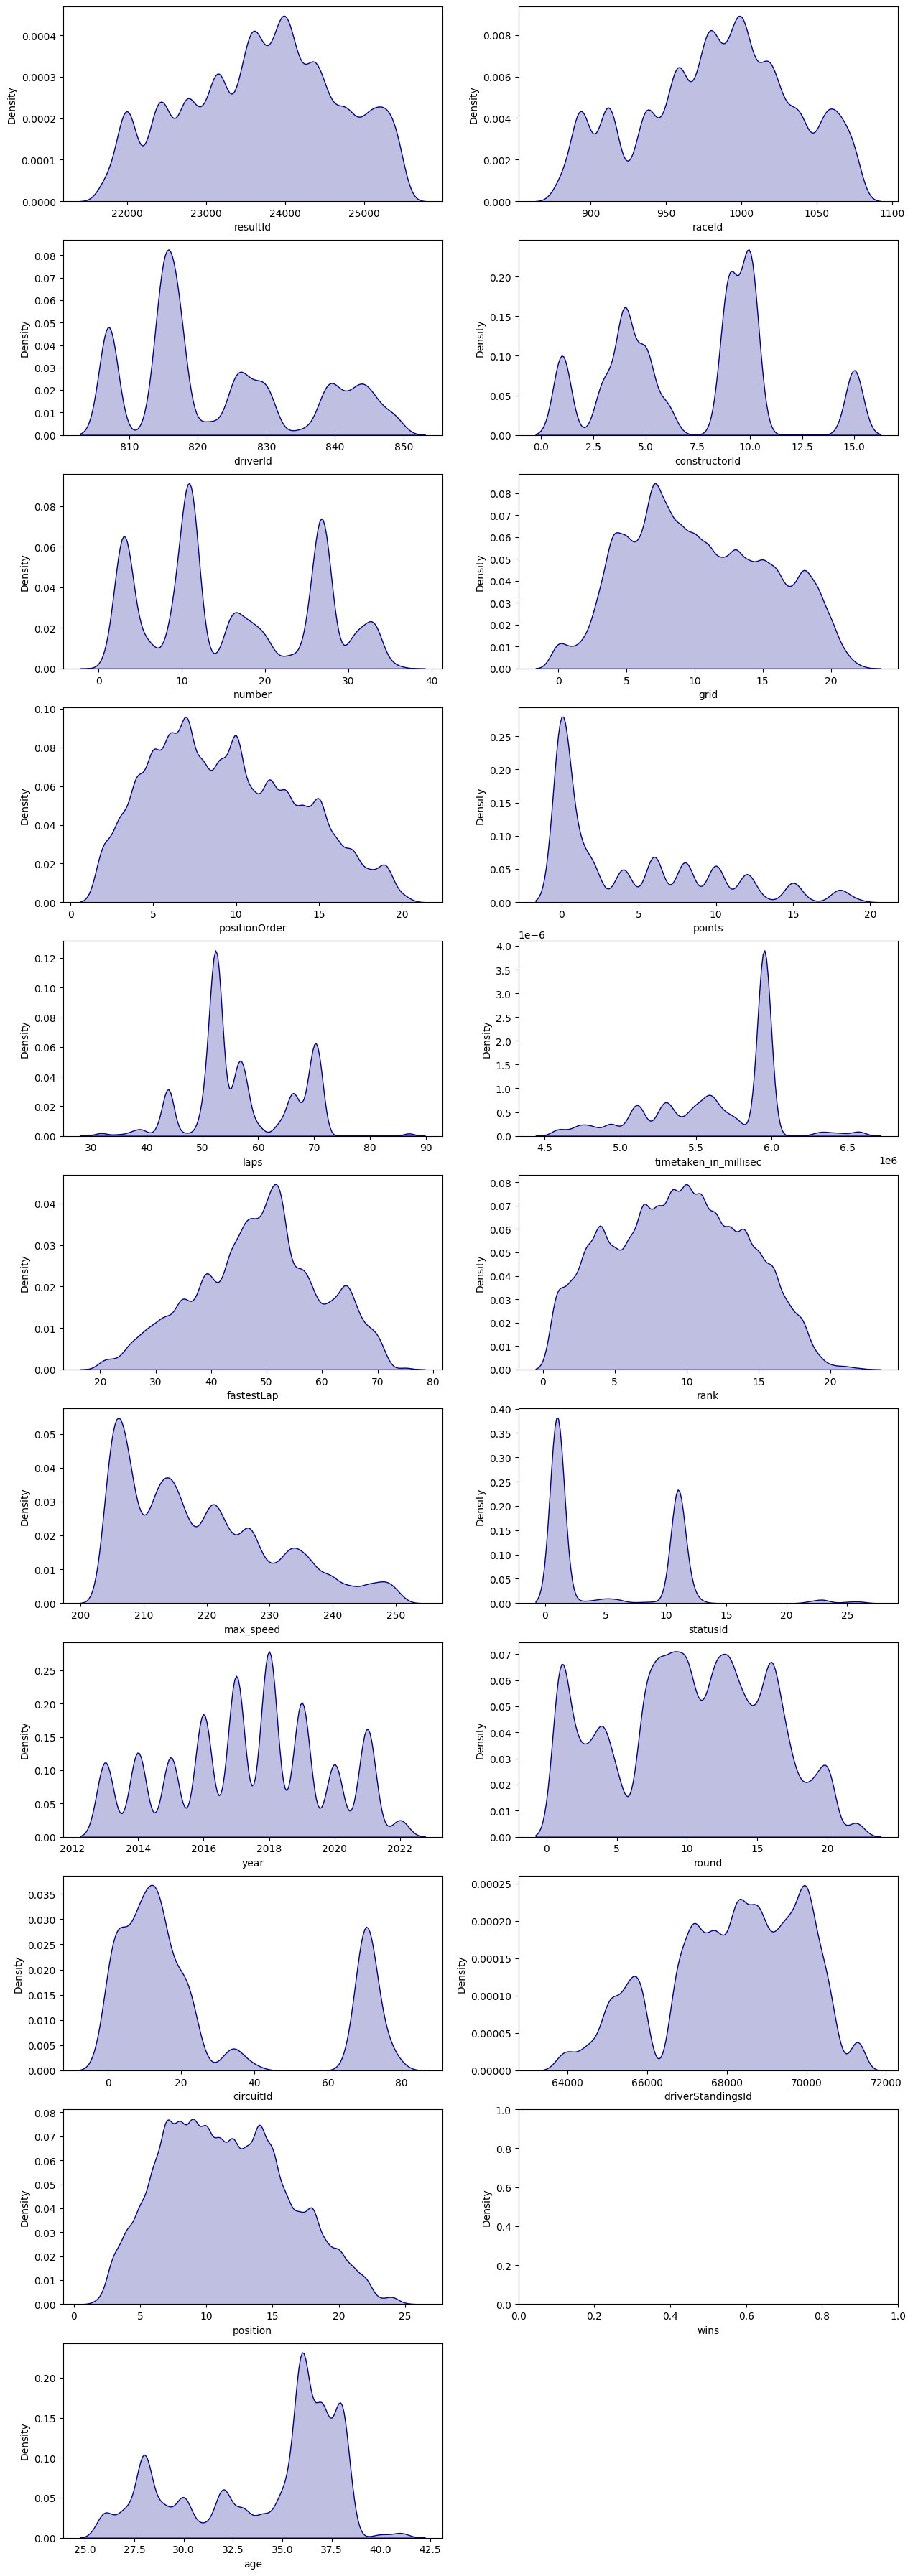

In [64]:
# kde plot for checking the normalization 

plt.figure(figsize=(15,50)) 
for i,j in zip(num,range(1,len(num)+1)):
    plt.subplot(12,2,j)
    sns.kdeplot(df[i],fill=True,color='darkblue')
plt.show()

In [66]:
df.skew(numeric_only=True)

resultId                -0.126882
raceId                  -0.182570
driverId                 0.519679
constructorId            0.210072
number                   0.234947
grid                     0.180974
positionOrder            0.332322
points                   0.952799
laps                     0.221338
timetaken_in_millisec   -0.615042
fastestLap              -0.155182
rank                     0.047163
max_speed                0.717552
statusId                 0.913723
year                    -0.114123
round                   -0.092068
circuitId                0.988905
driverStandingsId       -0.457409
position                 0.277132
wins                     0.000000
age                     -0.694008
dtype: float64

Still some columns are skewed even after outlier removal and skewness can be normalized during ML part

In [68]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [69]:
for i in cat:
    df[i] = le.fit_transform(df[i])
df.head()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,timetaken_in_millisec,...,grand_prix,driver_code,nationality,driverStandingsId,position,wins,company_name,status,driver_name,age
2744516,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,2,2,3,64699,10,0,1,9,19,40.0
2744517,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,2,2,3,64393,13,0,1,9,19,40.0
2744518,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,2,2,3,64417,14,0,1,9,19,40.0
2744519,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,2,2,3,64441,14,0,1,9,19,40.0
2744520,21719,880,814,10,14.0,9,8,4.0,58,5471674.0,...,2,2,3,64465,15,0,1,9,19,40.0


In [70]:
x = df.drop('driver_name',axis=1)
y = df.driver_name

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_text,y_train,y_text = train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
# importing ML libraries 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import tree

In [74]:
clt = DecisionTreeClassifier(max_depth=5,random_state=1234)
clt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1234
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [76]:
tree.export_text(clt)

'|--- feature_2 <= 810.00\n|   |--- class: 17\n|--- feature_2 >  810.00\n|   |--- feature_2 <= 816.00\n|   |   |--- feature_25 <= 38.00\n|   |   |   |--- class: 22\n|   |   |--- feature_25 >  38.00\n|   |   |   |--- feature_2 <= 813.50\n|   |   |   |   |--- class: 18\n|   |   |   |--- feature_2 >  813.50\n|   |   |   |   |--- class: 19\n|   |--- feature_2 >  816.00\n|   |   |--- feature_19 <= 0.50\n|   |   |   |--- class: 4\n|   |   |--- feature_19 >  0.50\n|   |   |   |--- feature_4 <= 32.00\n|   |   |   |   |--- feature_19 <= 13.50\n|   |   |   |   |   |--- class: 3\n|   |   |   |   |--- feature_19 >  13.50\n|   |   |   |   |   |--- class: 5\n|   |   |   |--- feature_4 >  32.00\n|   |   |   |   |--- feature_2 <= 835.50\n|   |   |   |   |   |--- class: 15\n|   |   |   |   |--- feature_2 >  835.50\n|   |   |   |   |   |--- class: 21\n'

In [80]:
fn = list(df.columns)
fn.remove('driver_name')

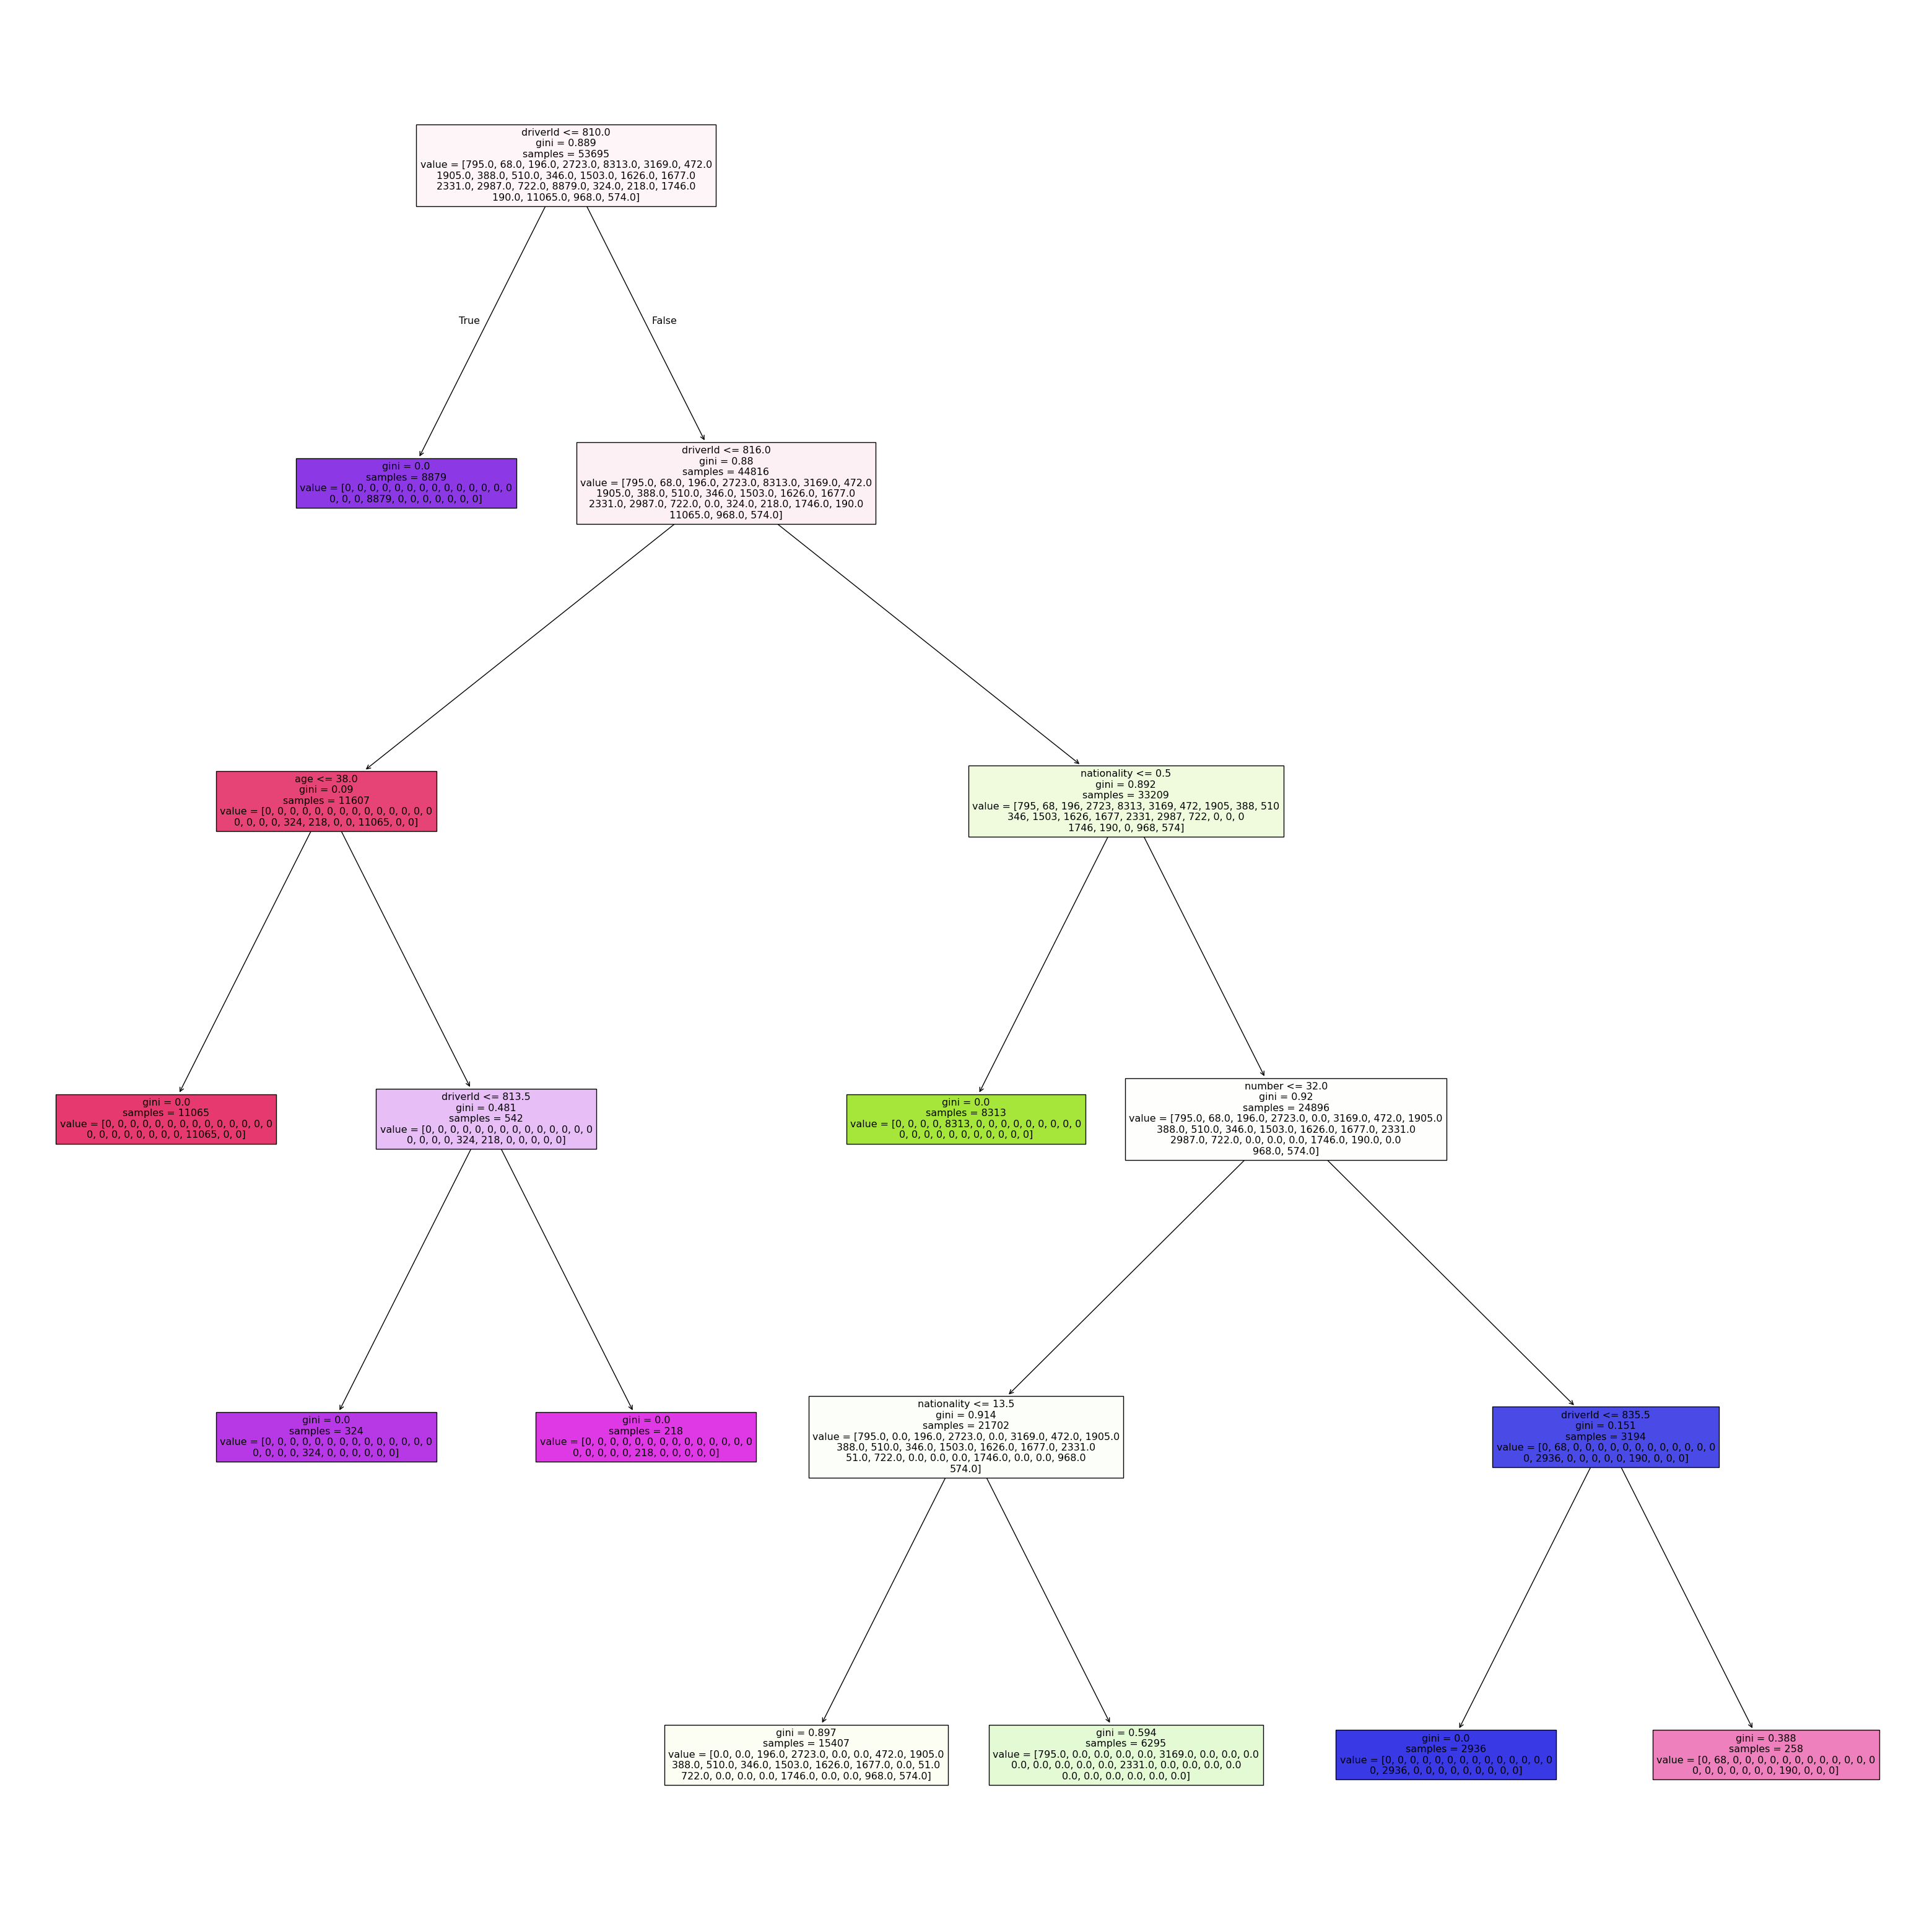

In [84]:
fig = plt.figure(figsize=(40,40))
_ = tree.plot_tree(clt,feature_names=fn,filled = True)

In [85]:
# classification ML algorithms 

lr = LogisticRegression(solver='sag')
dt = DecisionTreeClassifier()
rn = RandomForestClassifier()
knn = KNeighborsClassifier()
gb = GaussianNB()
sgd = SGDClassifier()

In [88]:
li = [lr,dt,rn,knn,gb,sgd]
d = {}
for i in li: 
    i.fit(x_train,y_train)
    ypred = i.predict(x_text)
    print(i,":",accuracy_score(ypred,y_text)*100)
    d.update({str(i):i.score(x_text,y_text)*100})

C:\Users\Sam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(solver='sag') : 21.03694874851013
DecisionTreeClassifier() : 100.0
RandomForestClassifier() : 100.0
KNeighborsClassifier() : 77.64451728247914
GaussianNB() : 68.91388557806913
SGDClassifier() : 4.797377830750894


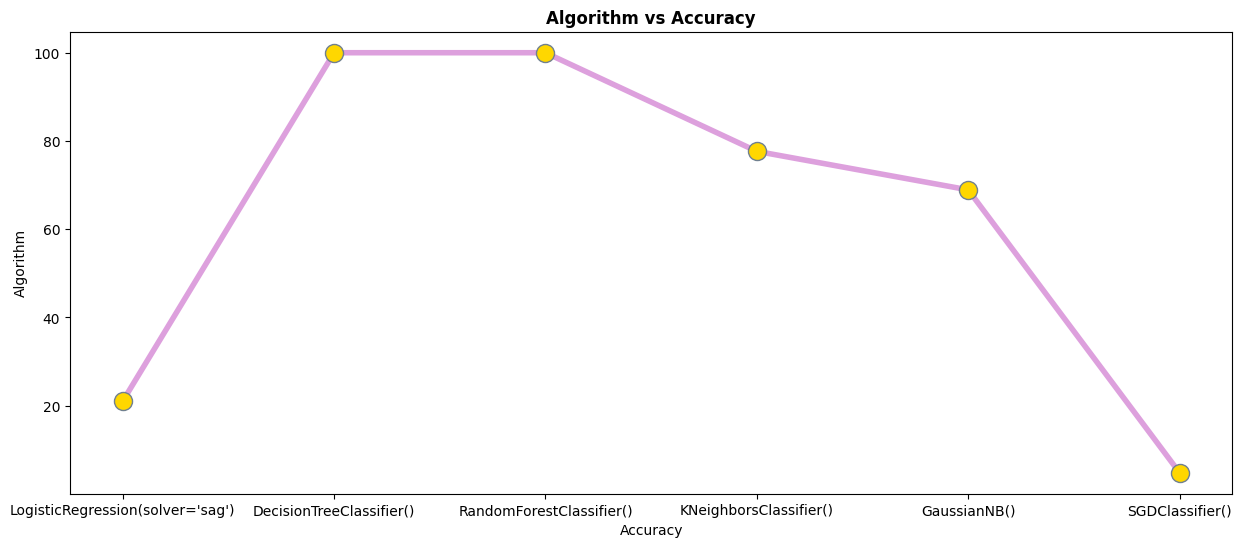

In [92]:
plt.figure(figsize=(15,6))
plt.title("Algorithm vs Accuracy",fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
plt.plot(d.keys(),d.values(),marker='o',color='plum',linewidth=4,markersize=13,
         markerfacecolor='gold',markeredgecolor='slategray')
plt.show()

As you can see, the accuracy of basic algorithm (logistic) and SGD is not good as expected. Since the data are skewed, so it can be fixed by scaling the data.

In [97]:
from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler().fit(x_train)
X_train_norm = norm.transform(x_train)
X_test_norm = norm.transform(x_text)

In [98]:
li = [lr,dt,rn,knn,gb,sgd]
di = {}
for i in li:
    i.fit(X_train_norm,y_train)
    ypred = i.predict(X_test_norm)
    print(i,":",accuracy_score(ypred,y_text)*100)
    di.update({str(i):i.score(X_test_norm,y_text)*100})

LogisticRegression(solver='sag') : 100.0
DecisionTreeClassifier() : 100.0
RandomForestClassifier() : 100.0
KNeighborsClassifier() : 100.0
GaussianNB() : 100.0
SGDClassifier() : 100.0


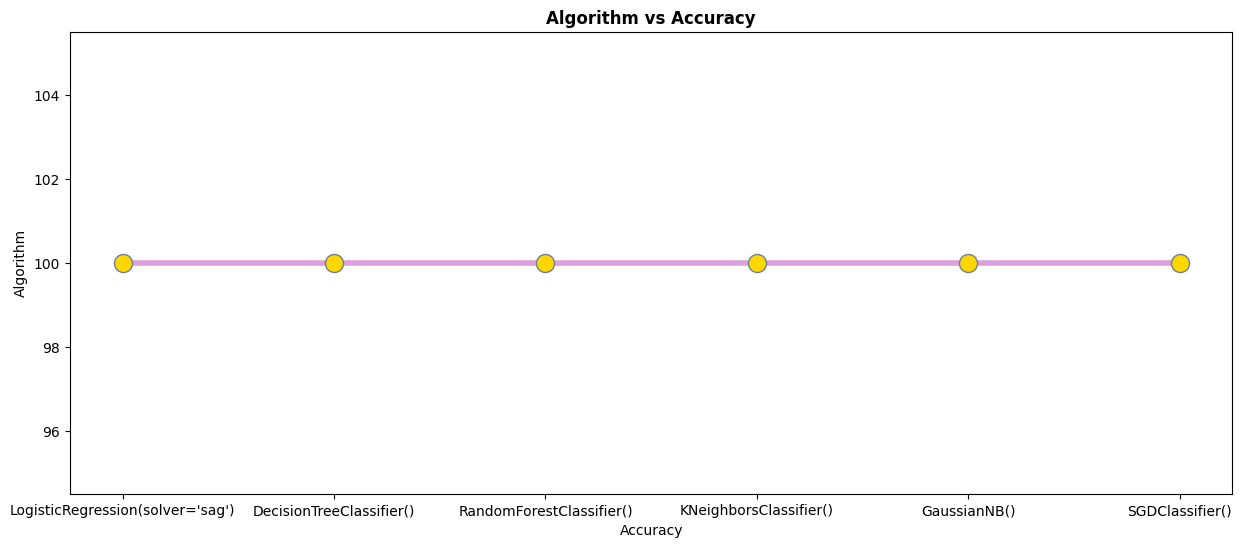

In [99]:
plt.figure(figsize=(15,6))
plt.title("Algorithm vs Accuracy",fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
plt.plot(di.keys(),di.values(),marker='o',color='plum',linewidth=4,markersize=13,
         markerfacecolor='gold',markeredgecolor='slategray')
plt.show()